# DataPrep_EDA: Data Exploration and Cleaning

This notebook shows:
1. Data sources and links
2. Raw data samples
3. Cleaned data samples
4. Simple visualizations
5. Cleaning impact

## 1. DATA SOURCES

### DIABETES DATA
- **Pima Indians Diabetes**: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
- **UCI Repository**: https://archive.ics.uci.edu/dataset/34/diabetes
- **File**: `diabetesData/diabetes.csv`
- **Raw Data Size**: 768 rows × 9 columns

### CARDIOVASCULAR DATA
- **Cardio Dataset**: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
- **Framingham Study**: https://www.kaggle.com/datasets/amanajmera1/framingham-heart-study-dataset
- **Cleveland Heart**: https://archive.ics.uci.edu/dataset/29/heart+disease
- **Files**: `cardiovascularData/cardio_train.csv`, `framingham.csv`, `processed.cleveland.data`

### KIDNEY DISEASE DATA
- **UCI Kidney**: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease
- **File**: `kidneyData/kidney_disease.csv`
- **Raw Data Size**: 400 rows × 25 columns

### API DATA
- **MarkerDB API**: http://markerdb.ca/api/v1/generalapi/generalrequest
- **Endpoint**: `http://markerdb.ca/api/v1/generalapi/generalrequest`
- **GET Example**: `?api_key=537ff5a9c7b427cd676e9cb288aeff4b&category=Diagnostic&biomarker_type=Chemical&page=1`

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import os


## 2. DIABETES DATA: RAW vs CLEAN

In [46]:
raw_diabetes = pd.read_csv('../../diabetesData/diabetes.csv')
clean_diabetes = pd.read_csv('../final_cleaned_data_files/diabetes_cleaned.csv')

print("Raw data")
print(f"Shape: {raw_diabetes.shape}")
print(f"Missing values: {raw_diabetes.isnull().sum().sum()}")
print(f"Duplicates: {raw_diabetes.duplicated().sum()}")

print("\nFirst 3 rows:")
print(raw_diabetes.head(3))

Raw data
Shape: (768, 9)
Missing values: 0
Duplicates: 0

First 3 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [47]:
print("Clean data")
print(f"Shape: {clean_diabetes.shape}")
print(f"Missing values: {clean_diabetes.isnull().sum().sum()}")
print(f"Duplicates: {clean_diabetes.duplicated().sum()}")
print("\nFirst 3 rows:")
print(clean_diabetes.head(3))

Clean data
Shape: (768, 9)
Missing values: 0
Duplicates: 0

First 3 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


## 3. DIABETES VISUALIZATIONS

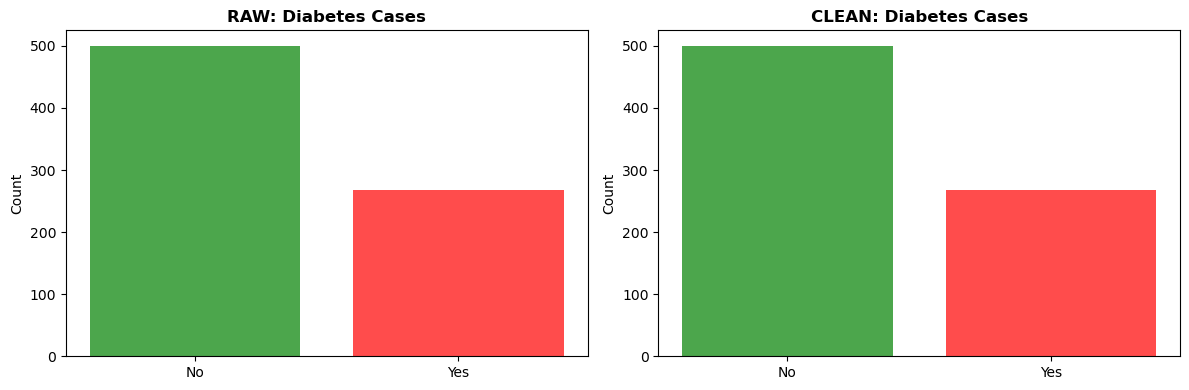

In [48]:
# Simple visualization: Diabetes target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Raw data
raw_counts = raw_diabetes['Outcome'].value_counts().sort_index()
ax1.bar(['No', 'Yes'], raw_counts.values, color=['green', 'red'], alpha=0.7)
ax1.set_title('RAW: Diabetes Cases', fontweight='bold')
ax1.set_ylabel('Count')

# Clean data (uses Outcome column, not diabetes_label)
clean_counts = clean_diabetes['Outcome'].value_counts().sort_index()
ax2.bar(['No', 'Yes'], clean_counts.values, color=['green', 'red'], alpha=0.7)
ax2.set_title('CLEAN: Diabetes Cases', fontweight='bold')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 4. CARDIOVASCULAR DATA: RAW vs CLEAN

In [49]:
# Load data
raw_cardio = pd.read_csv('../../cardiovascularData/cardio_train.csv', sep=';')
clean_cardio = pd.read_csv('../final_cleaned_data_files/cardio_train_cleaned.csv')

print("Raw data")
print(f"Shape: {raw_cardio.shape}")
print(f"Columns: {raw_cardio.columns.tolist()[:5]}...")
print("\nFirst 3 rows:")
print(raw_cardio.head(3))

Raw data
Shape: (70000, 13)
Columns: ['id', 'age', 'gender', 'height', 'weight']...

First 3 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  


In [50]:
print("Clean data")
print(f"Shape: {clean_cardio.shape}")
print(f"Columns: {clean_cardio.columns.tolist()[:5]}...")
print("\nFirst 3 rows:")
print(clean_cardio.head(3))


Clean data
Shape: (68705, 12)
Columns: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo']...

First 3 rows:
   gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  \
0       2     168    62.0    110     80            1     1      0     0   
1       1     156    85.0    140     90            3     1      0     0   
2       1     165    64.0    130     70            3     1      0     0   

   active  cvd_label  age_years  
0       1          0  50.357290  
1       1          1  55.381246  
2       0          1  51.627652  


## 5. CARDIOVASCULAR VISUALIZATIONS

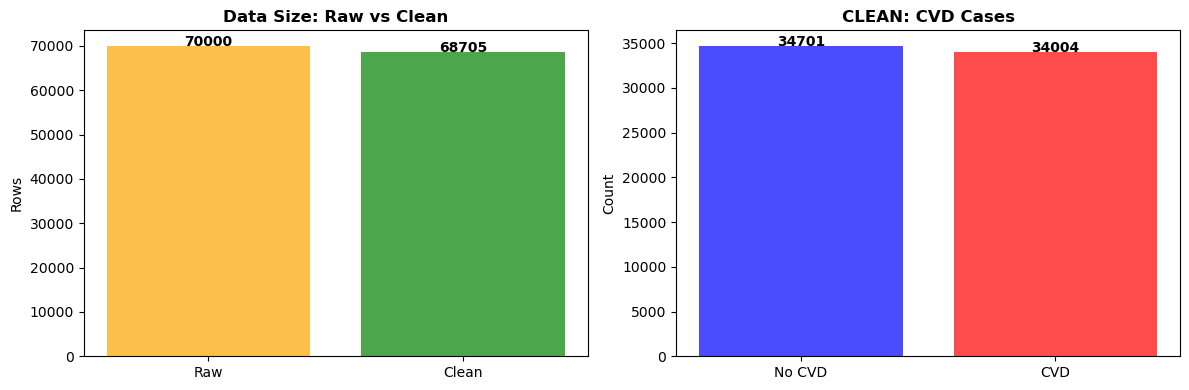

In [51]:
# Simple visualization: Cardiovascular data size and target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Data size comparison
ax1.bar(['Raw', 'Clean'], [len(raw_cardio), len(clean_cardio)], color=['orange', 'green'], alpha=0.7)
ax1.set_title('Data Size: Raw vs Clean', fontweight='bold')
ax1.set_ylabel('Rows')
ax1.text(0, len(raw_cardio), str(len(raw_cardio)), ha='center', fontweight='bold')
ax1.text(1, len(clean_cardio), str(len(clean_cardio)), ha='center', fontweight='bold')

# Target variable (assuming cvd_label exists in clean data)
target_clean = clean_cardio['cvd_label'].value_counts().sort_index()
ax2.bar(['No CVD', 'CVD'], target_clean.values, color=['blue', 'red'], alpha=0.7)
ax2.set_title('CLEAN: CVD Cases', fontweight='bold')
ax2.set_ylabel('Count')
for i, v in enumerate(target_clean.values):
    ax2.text(i, v, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. KIDNEY DATA: RAW vs CLEAN

In [52]:
# Load data
raw_kidney = pd.read_csv('../../kidneyData/kidney_disease.csv')
clean_kidney = pd.read_csv('../final_cleaned_data_files/kidney_cleaned.csv')

print("Raw Kidney Data")
print(f"Shape: {raw_kidney.shape}")
print(f"Missing values: {raw_kidney.isnull().sum().sum()}")
print("\nFirst 3 rows:")
print(raw_kidney.head(3))

Raw Kidney Data
Shape: (400, 26)
Missing values: 1009

First 3 rows:
   id   age    bp    sg   al   su     rbc      pc         pcc          ba  \
0   0  48.0  80.0  1.02  1.0  0.0     NaN  normal  notpresent  notpresent   
1   1   7.0  50.0  1.02  4.0  0.0     NaN  normal  notpresent  notpresent   
2   2  62.0  80.0  1.01  2.0  3.0  normal  normal  notpresent  notpresent   

   ...  pcv    wc   rc  htn   dm  cad appet  pe  ane classification  
0  ...   44  7800  5.2  yes  yes   no  good  no   no            ckd  
1  ...   38  6000  NaN   no   no   no  good  no   no            ckd  
2  ...   31  7500  NaN   no  yes   no  poor  no  yes            ckd  

[3 rows x 26 columns]


In [53]:
print("Clean data")
print(f"Shape: {clean_kidney.shape}")
print(f"Missing values: {clean_kidney.isnull().sum().sum()}")
print("\nFirst 3 rows:")
print(clean_kidney.head(3))

Clean data
Shape: (400, 25)
Missing values: 0

First 3 rows:
    age    bp    sg   al   su     rbc      pc         pcc          ba    bgr  \
0  48.0  80.0  1.02  1.0  0.0  normal  normal  notpresent  notpresent  121.0   
1   7.0  50.0  1.02  4.0  0.0  normal  normal  notpresent  notpresent  121.0   
2  62.0  80.0  1.01  2.0  3.0  normal  normal  notpresent  notpresent  423.0   

   ...  pcv    wc   rc  htn   dm cad appet  pe  ane ckd_label  
0  ...   44  7800  5.2  yes  yes  no  good  no   no         1  
1  ...   38  6000  5.2   no   no  no  good  no   no         1  
2  ...   31  7500  5.2   no  yes  no  poor  no  yes         1  

[3 rows x 25 columns]


## 7. KIDNEY VISUALIZATIONS

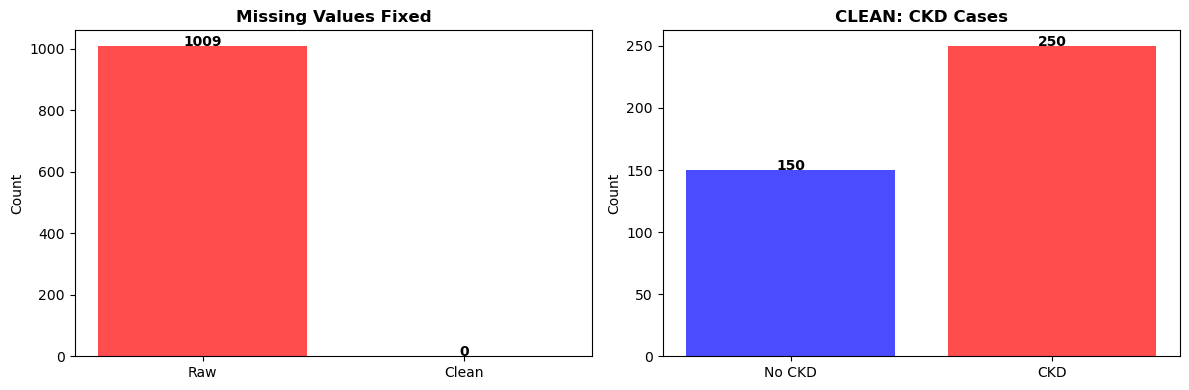

In [54]:
# Simple visualization: Kidney data quality and target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Missing values: Raw vs Clean
missing_raw = raw_kidney.isnull().sum().sum()
missing_clean = clean_kidney.isnull().sum().sum()
ax1.bar(['Raw', 'Clean'], [missing_raw, missing_clean], color=['red', 'green'], alpha=0.7)
ax1.set_title('Missing Values Fixed', fontweight='bold')
ax1.set_ylabel('Count')
ax1.text(0, missing_raw, str(missing_raw), ha='center', fontweight='bold')
ax1.text(1, missing_clean, str(missing_clean), ha='center', fontweight='bold')

# CKD cases (clean data)
ckd_counts = clean_kidney['ckd_label'].value_counts().sort_index()
ax2.bar(['No CKD', 'CKD'], ckd_counts.values, color=['blue', 'red'], alpha=0.7)
ax2.set_title('CLEAN: CKD Cases', fontweight='bold')
ax2.set_ylabel('count')

plt.tight_layout()
plt.show()

## 8. API DATA: BIOMARKERS

In [55]:
# Load API data (if it exists)
api_path = '../final_cleaned_data_files/cleaned_markerdb_api.csv'
if os.path.exists(api_path):
    api_df = pd.read_csv(api_path)
    print("MARKERDB API DATA")
    print(f"Shape: {api_df.shape}")
    print(f"\nBiomarkers per condition:")
    print(api_df['condition_name'].value_counts())
    print(f"\nSample biomarkers:")
    print(api_df.head(10))
else:
    print("API data file not reached:", api_path)
    api_df = None

MARKERDB API DATA
Shape: (159, 4)

Biomarkers per condition:
condition_name
chronic kidney disease                                                  28
diabetes mellitus type 2                                                25
kidney disease                                                          17
autosomal dominant polycystic kidney disease                            15
hypertension                                                            11
chronic renal failure                                                   10
heart failure                                                           10
lipoid congenital adrenal hyperplasia                                    7
congenital adrenal insufficiency with 46,xy sex reversal                 7
stroke                                                                   4
congenital adrenal hyperplaia due to 17-alpha-hydroxylase deficiency     3
nephrotic syndrome                                                       3
glycolic aciduria       

## 9. API VISUALIZATION

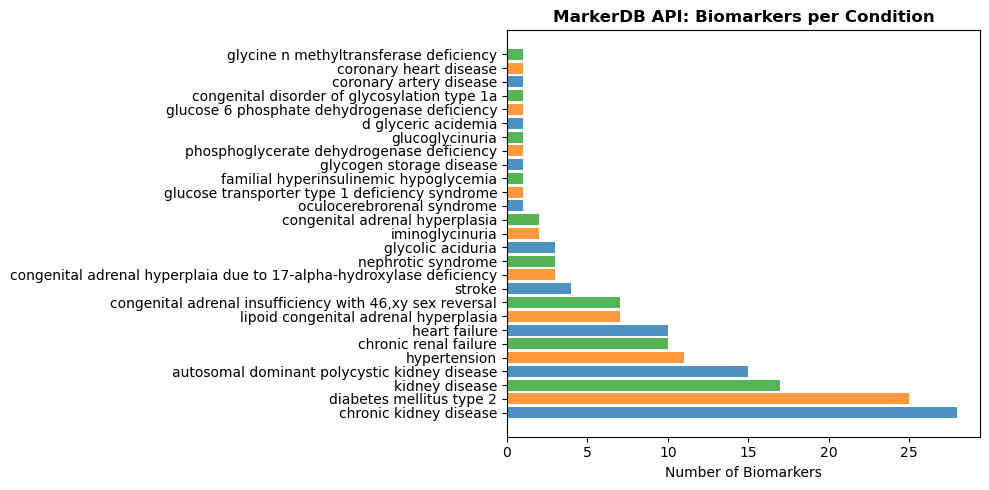

In [58]:
# API biomarkers
if api_df is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    condition_counts = api_df['condition_name'].value_counts()
    ax.barh(condition_counts.index, condition_counts.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)
    ax.set_xlabel('Number of Biomarkers')
    ax.set_title('MarkerDB API: Biomarkers per Condition', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("(file not found)")

## 10. CLEANING SUMMARY

In [57]:
print("\n" + "="*70)
print("CLEANING SUMMARY")
print("="*70)

print("\n1. DIABETES")
print(f"   Raw: {len(raw_diabetes)} rows")
print(f"   Clean: {len(clean_diabetes)} rows")
print(f"   Removed: {len(raw_diabetes) - len(clean_diabetes)} rows")

print("\n2. CARDIOVASCULAR")
print(f"   Raw: {len(raw_cardio)} rows")
print(f"   Clean: {len(clean_cardio)} rows")
print(f"   Removed: {len(raw_cardio) - len(clean_cardio)} rows")

print("\n3. KIDNEY")
print(f"   Raw: {len(raw_kidney)} rows")
print(f"   Clean: {len(clean_kidney)} rows")
print(f"   Removed: {len(raw_kidney) - len(clean_kidney)} rows")

if api_df is not None:
    print("\n4. API")
    print(f"   Biomarkers: {len(api_df)}")
    print(f"   Conditions: {len(api_df['condition_name'].unique())}")
else:
    print("\n4. API - Not available (run cdc_api_data_cleaning.ipynb first)")




CLEANING SUMMARY

1. DIABETES
   Raw: 768 rows
   Clean: 768 rows
   Removed: 0 rows

2. CARDIOVASCULAR
   Raw: 70000 rows
   Clean: 68705 rows
   Removed: 1295 rows

3. KIDNEY
   Raw: 400 rows
   Clean: 400 rows
   Removed: 0 rows

4. API
   Biomarkers: 159
   Conditions: 27
